In [1]:
# performance testing for metapop1
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import torch
import pickle
from metapop_value_iteration import _act, build_optimal_controller_fully_observable
from metapop1 import metapop1
import numpy as np
import pandas as pd


def avgperformance(env, config, policy_printout=False):
    device = torch.device('cpu')  # Force CPU usage
    policytype = config['policytype']
    num_episodes = config['num_episodes']
    if policytype == 0: # Value iteration
        print( 'policy type: value iteration')
        with open(f'./value_iteration/VI_controller_setting{config["VIenvid"]}.pkl', 'rb') as f:
            ctrl = pickle.load(f)
        Policy = ctrl['policy']
        # reinitiate the environment
        settings = ctrl['envinfo']
        print(settings)
        env = metapop1(settings)
    elif policytype == 1: # ppo
        print(f'policy type: PPO, seed: {config["pposeed"]}, paramset: {config["ppoparamset"]}')
        wd = f"./PPO_results/good_ones/seed{config['pposeed']}_paramid{config['ppoparamset']}"
        # re-initialize the environment
        if config['specificepi'] is None:
            with open(f'{wd}/config.txt', 'r') as f:
                lines = f.readlines()
            for line in lines:
                if 'envconfig' in line:
                    obsvarline = line
                    break
            # parse the dictionary string of envconfig and evaluate it to get the obsvars
            envconfigstr = obsvarline.split('envconfig: ')[1].strip()
            envconfigdict = eval(envconfigstr)
            env = metapop1(envconfigdict)

        # find filename that starts with bestPolicyNetwork
        if config['specificepi'] is None:
            for filename in os.listdir(wd):
                if filename.startswith("bestPolicyNetwork"):
                    model_path = os.path.join(wd, filename)
                    break
            for filename in os.listdir(wd):
                if filename.startswith("bestPolicyrms"):
                    rms_path = os.path.join(wd, filename)
                    break
            with open(rms_path, "rb") as f:
                rms = pickle.load(f)
        else:
            print(f"testing specific seed: {config['specificepi']}")
            model_path = f"{wd}/PolicyNetwork_{env.envID}_par{env.paramsetID}_set{env.settingID}_PPO2_episode{config['specificepi']}.pt"
            rms_model_path = f"{wd}/rms_{env.envID}_par{env.paramsetID}_set{env.settingID}_PPO2_episode{config['specificepi']}.pkl"
            with open(rms_model_path, "rb") as f:
                rms = pickle.load(f)

        Policy = torch.load(model_path, weights_only=False)
        # find filename that starts with bestPolicyrms

    elif policytype == 2: # heuristics
        if config['heuristics'] == 0:
            print( 'policy type: heuristics, no action')
        elif config['heuristics'] == 1:
            print( 'policy type: heuristics, full action')
        elif config['heuristics'] == 2:
            print( 'policy type: heuristics, random action')
        elif config['heuristics'] == 3:
            print( 'policy type: heuristics, supplement if X=0 or H=0 and restore H=0\'s in the order of highest incoming weight sum')
        elif config['heuristics'] == 4:
            print( 'policy type: heuristics, supplement if X=0 and restore H=0\'s in the order of highest incoming weight sum')
        elif config['heuristics'] == 5:
            print( 'policy type: heuristics, custom heuristics')
    rewards = []
    avgconnectivity = []
    avgeprob = []
    avgcprob = []
    occfraction = []
    goodHfraction = []
    survivaltime = []
    restore_fraction = []
    supp_fraction = []
    for i in range(num_episodes):
        obs, state = env.reset()
        input = obs.copy()
        if policytype == 1:
            input = rms.normalize(input)
        done = False
        ep_reward = 0
        avgconnectivity_per_episode = []
        avgeprob_per_episode = []
        avgcprob_per_episode = []
        occfraction_per_episode = []
        goodHfraction_per_episode = []
        survivaltime_per_episode = []
        restore_fraction_per_episode = []
        supp_fraction_per_episode = []
        tt=0
        while not done:
            if policytype == 0:
                action = _act(env, Policy, input)
            elif policytype == 1:
                with torch.no_grad():

                    tensorinput = torch.tensor(input, dtype=torch.float32).unsqueeze(0)  # Add batch dimension
                    action = Policy.getaction(tensorinput, get_action_only=True)
                    action = torch.squeeze(action).cpu().detach().numpy()
            elif policytype == 2: # heuristics
                if config['heuristics'] == 0: # no action
                    action = np.zeros(env.aS_dim + env.aR_dim)
                elif config['heuristics'] == 1: # full action
                    aR = np.zeros(env.aR_dim)
                    rlen = min(env.kR, env.aR_dim)
                    aR[np.random.choice(np.arange(env.aR_dim), size=rlen, replace=False)] = 1
                    aS = np.zeros(env.aS_dim)
                    slen = min(env.kS, env.aS_dim)
                    aS[np.random.choice(np.arange(env.aS_dim), size=slen, replace=False)] = 1
                    action = np.concatenate((aR, aS))
                elif config['heuristics'] == 2: # random action
                    aR = np.zeros(env.aR_dim, dtype=int)
                    rlen = min(env.kR, env.aR_dim)
                    Ridx = np.random.choice(np.arange(env.aR_dim), size=rlen, replace=False)
                    aR[Ridx] = np.random.choice([0,1], size=rlen)
                    aS = np.zeros(env.aS_dim)
                    slen = min(env.kS, env.aS_dim)
                    Sidx = np.random.choice(np.arange(env.aS_dim), size=slen, replace=False)
                    aS[Sidx] = np.random.choice([0,1], size=slen)
                    action = np.concatenate((aR, aS))
                elif config['heuristics'] in [3,4]: # supplement if X=0 or H=0 (if config=3, supplement only X=0 for config=4)and restore H=0's in the order of highest incoming weight sum.
                    aR = np.zeros(env.aR_dim, dtype=int)
                    aS = np.zeros(env.aS_dim, dtype=int)
                    X = env.state[:,env.oidx['X']] if env.dim2state == 1 else env.state[env.oidx['X']]
                    H = env.state[:,env.oidx['H']] if env.dim2state == 1 else env.state[env.oidx['H']]
                    incoming_weights = env.w.sum(axis=0)
                    if config['heuristics'] == 3:
                        sidx = np.where((X == 0) | (H == 0))[0]
                    else:
                        sidx = np.where(X == 0)[0]
                    aS[sidx] = 1
                    h0 = np.where(H == 0)[0]
                    if h0.size > 0:
                        h0_sorted = h0[np.argsort(incoming_weights[h0])[::-1]]
                        aR[h0_sorted[:env.kR]] = 1
                    action = np.concatenate((aR, aS))
                elif config['heuristics'] == 5: # custom heuristics
                    action = env.heuristic_action()
            tt += 1
            if policy_printout:
                print(f't: {input[env.oidx["t"][0]]},  X: {input[env.oidx["X"]]}, aS: {action[env.aidx["aS"]]}, H: {input[env.oidx["H"]]}, Z: {input[env.oidx["Z"]]}, aR: {action[env.aidx["aR"]]}')
            obs, reward, done, info = env.step(action)
            input = env.obs.copy()
            if policytype == 1:
                input = rms.normalize(input)
            ep_reward += reward
            avgconnectivity_per_episode.append(np.mean(info['connectivity']))
            avgeprob_per_episode.append(np.mean(info['extinction_prob']))
            avgcprob_per_episode.append(np.mean(info['colonization_prob']))
            occfraction_per_episode.append(np.mean(info['occupied_fraction']))
            goodHfraction_per_episode.append(np.mean(info['goodhabitat_fraction']))
            restore_fraction_per_episode.append(np.sum(action[0:env.patchnum])/env.patchnum)
            supp_fraction_per_episode.append(np.sum(action[env.patchnum:])/env.patchnum)
        avgconnectivity.append(np.mean(avgconnectivity_per_episode))
        avgeprob.append(np.mean(avgeprob_per_episode))
        avgcprob.append(np.mean(avgcprob_per_episode))
        occfraction.append(np.mean(occfraction_per_episode))
        goodHfraction.append(np.mean(goodHfraction_per_episode))
        survivaltime.append(tt)
        restore_fraction.append(np.mean(restore_fraction_per_episode))
        supp_fraction.append(np.mean(supp_fraction_per_episode))
        rewards.append(ep_reward)
        #if (i+1) % 100 == 0:
        #    print(f'Episode {i+1} done')
    summary = {'rewards': rewards, 'connectivity': avgconnectivity, 'extinction_prob': avgeprob, 'colonization_prob': avgcprob, 'occupied_fraction': occfraction, 'good_habitat_fraction': goodHfraction, 'survival_time': survivaltime, 'restore_fraction': restore_fraction, 'supp_fraction': supp_fraction}
    summary_df = pd.DataFrame(summary)
    
    print(f'patch num = {env.patchnum}')
    print(f'Average reward over {num_episodes} episodes: {np.mean(rewards):.2f}')
    print(f'Average connectivity: {np.mean(avgconnectivity):.2f}, Average extinction prob: {np.mean(avgeprob):.2f}, Average colonization prob: {np.mean(avgcprob):.2f}')
    print(f'Occupied fraction: Avg {np.mean(occfraction):.2f}, Std {np.std(occfraction):.2f}') 
    print(f'Good habitat fraction: Avg {np.mean(goodHfraction):.2f}, Std {np.std(goodHfraction):.2f}')
    print(f'Average survival time: {np.mean(survivaltime):.2f}')
    # add average in the first row of summary_df
    summary_df.loc[-1] = [np.mean(rewards), np.mean(avgconnectivity), np.mean(avgeprob), np.mean(avgcprob), np.mean(occfraction), np.mean(goodHfraction), np.mean(survivaltime), np.mean(restore_fraction), np.mean(supp_fraction)]
    summary_df.index = summary_df.index + 1  # shift index
    summary_df = summary_df.sort_index()  # sort by index
    # save as csv
    random_seed = np.random.randint(0, 100000000)
    summary_df.to_csv(f'./performance_summary/performance_summary_{random_seed}.csv', index=False)

    return summary


# policytype: 0 for value iteration, 1 for ppo, 2 for heuristics
# n=10 low centrality -> seednum = 839394, paramid = 35, parid = 10, setid = 22

config = {'policytype': 2, 'ppoparamset': 32, 'pposeed': 398845, 'specificepi': None, 'VIenvid': 19, 'heuristics': 5, 'num_episodes': 10000}# [37400,33200]
settings = {'settingID': 23}
if type(config['specificepi']) == list:
    for seed in config['specificepi']:
        env = metapop1(settings)
        newconfig = config.copy()
        newconfig['specificepi'] = seed
        summary = avgperformance(env,config=newconfig, policy_printout=False)
else:
    env = metapop1(settings)
    summary = avgperformance(env,config=config, policy_printout=False)
1.6
#cost = [0.162]
#a0 = [0.1]
#for j in range(len(cost)):
#    for k in range(len(a0)):
#        perfs = []
#        for i in [0,3]:#range(4):
#            config = {'policytype': 2, 'envid': 5, 'POMDP': 0, 'heuristics': i, 'num_episodes': 1000}
#            settings = {'settingID': 23}
#            env = metapop1(settings)
#            env.cr = cost[j]
#            env.cs = cost[j]
#            env.alph0 = a0[k]
#            summary = avgperformance(env,config=config, policy_printout=False)
#            perfs.append(np.mean(summary['rewards']))
#        #print(f'cost: {cost[j]}, a0: {a0[k]}, performance: {perfs[0]:.2f}/{perfs[1]:.2f}/{perfs[2]:.2f}/{perfs[3]:.2f}')

policy type: heuristics, custom heuristics
patch num = 10
Average reward over 10000 episodes: 5.22
Average connectivity: 1.43, Average extinction prob: 0.28, Average colonization prob: 0.16
Occupied fraction: Avg 0.72, Std 0.03
Good habitat fraction: Avg 0.77, Std 0.04
Average survival time: 30.00


1.8

(array([  34.,  284.,  933., 2247., 2911., 2304., 1008.,  242.,   33.,
           4.]),
 array([-2.56 , -0.563,  1.434,  3.431,  5.428,  7.425,  9.422, 11.419,
        13.416, 15.413, 17.41 ]),
 <BarContainer object of 10 artists>)

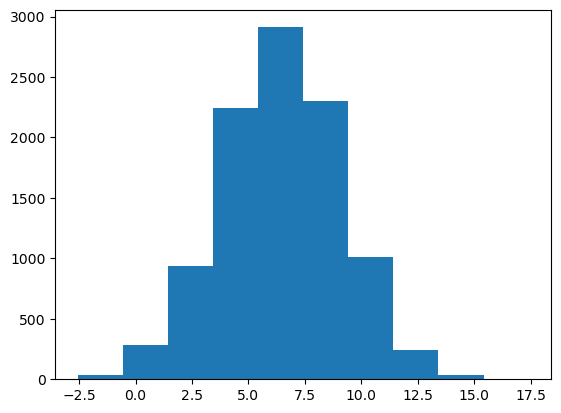

In [20]:
import os 
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
import matplotlib.pyplot as plt

plt.hist(summary['rewards'])